In [1]:
from Objects.Transformations import *
from Objects.WSBM import *
from Objects.TWSBMInstance import *

from Computation.Computation import *
from Computation.ExtraMetrics import *

from Plotting.Plotting import *
from Plotting.ArtisticPlotting import *

eps = False

def sample_in_rectangle(x_a=0, x_b=1, y_a=0, y_b=1, props=None, traversal='row-major', remove_black=False):
	props = np.asarray(props if props is not None else [0.1, 0.5, 0.9])
	N = props.size
	xs = x_a + props * (x_b - x_a)
	ys = y_a + props * (y_b - y_a)
	xx, yy = np.meshgrid(xs, ys, indexing='xy')
	ii, jj = np.meshgrid(np.arange(N), np.arange(N), indexing='xy')
	order = 'C' if traversal == 'row-major' else 'F'
	flat_x = xx.ravel(order=order)
	flat_y = yy.ravel(order=order)
	flat_i = ii.ravel(order=order)
	flat_j = jj.ravel(order=order)
	if remove_black and N >= 3:
		mask = ((flat_i + flat_j) % 2 == 0)
		flat_x = flat_x[mask]
		flat_y = flat_y[mask]
	return list(zip(flat_x, flat_y))

def plot_embeddings_grid(model, transforms, subfolder, 
						 rhos = RHOS, pis = PIS, model_params = sample_in_rectangle(), q_outliers = 0,
						 mode = 'Truth', ellipse = True, show_stats = True, seed = 0):
	emb_mode, p22 = EMB_MODES[0], P22S[0]
	metrics = {}
	for rho, pi in product(rhos, pis):
		metrics[(rho, pi)] = {}
		for p11, p12 in model_params:
			m = model(rho, pi, (p11, p12), p22 = p22)
			A, Z = m(42 + seed)
			metrics[(rho, pi)][m] = {}
			for t in transforms:
				#print(f"Simulating for rho={rho}, pi={pi}, model={model.name}, transformation={t.id}")
				metrics[(rho, pi)][m][t] = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z, emb_mode = emb_mode)
	plotter = Plotter(folder_path="", eps = eps)
	for rho, pi in product(rhos, pis):
		plotter.plot_embedding(rho, pi, metrics[(rho, pi)], subfolder = subfolder, q_outliers = q_outliers, 
						 mode = mode, ellipse = ellipse, show_stats = show_stats)

In [ ]:
rects = [sample_in_rectangle(), sample_in_rectangle(remove_black=True)]
transforms_lists_dic = dict(zip(
	['Transforms', 'Powers', 'Quantiles'],
	[TRANSFORMS, TRANSFORMS_POW, TRANSFORMS_QTL]
))

for model in MODELS:
	for ts_name, transforms in transforms_lists_dic.items():
		for rect in rects:
			plot_embeddings_grid(model, transforms, f'{len(rect)}{model.name}/{ts_name}', model_params = rect)

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:134: UserWa

In [ ]:
transforms = TRANSFORMS_QTL.copy() + [LogTransform()]
subfolder = 'C_true_Regret'


model = betaWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 0.2, 0.6, 1)[4:5], 
					 rhos = [0.25], pis = [0.1], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0.4, 0.65, 0.6, 1)[0:1], 
					 rhos = [0.5], pis = [0.5], q_outliers = 0.01)

model = lognormWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 1, 0.3, 0.4)[3:4], 
					 rhos = [0.1], pis = [0.1], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0, 0.25, 0.55, 0.65)[1:2], 
					 rhos = [0.25], pis = [0.25], q_outliers = 0.01)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0.4, 0.5, 0.8, 1)[0:1], 
					 rhos = [0.5], pis = [0.25], q_outliers = 0.01)

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")


" model = lognormWSBM\nplot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', \n\t\t\t\t\t model_params = sample_in_rectangle(0, 1, 0.3, 0.4)[3:4], \n\t\t\t\t\t rhos = [0.1], pis = [0.1], q_outliers = 0.01)\nplot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', \n\t\t\t\t\t model_params = sample_in_rectangle(0, 0.25, 0.55, 0.65)[1:2], \n\t\t\t\t\t rhos = [0.25], pis = [0.25], q_outliers = 0.01)\nplot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', \n\t\t\t\t\t model_params = sample_in_rectangle(0.4, 0.5, 0.8, 1)[0:1], \n\t\t\t\t\t rhos = [0.5], pis = [0.25], q_outliers = 0.01) "

In [5]:
transforms = TRANSFORMS_QTL.copy() + [LogTransform()]
subfolder = 'C_embed_Regret'

model = betaWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = sample_in_rectangle(0.5, 0.6, 0.25, 0.4)[6:7], 
					 rhos = [0.1], pis = [0.1], q_outliers = 0.01, seed = 1)

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")


In [2]:
transforms = [IdentityTransform(), LogTransform(), QuantileTransform(0.25), PowerTransform(2)]
subfolder = 'Example'

model = betaWSBM
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = [(0.1, 0.9)], 
					 rhos = [0.1], pis = [0.25], q_outliers = 0.01,
                     ellipse = False, show_stats = False)
plot_embeddings_grid(model, transforms, f'{subfolder}/{model.name}', 
					 model_params = [(0.1, 0.9)], 
					 rhos = [0.1], pis = [0.25], q_outliers = 0.01,
                     ellipse = False, mode = 'Prediction', show_stats = False)

c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")
c:\Users\Nicol\Documents\EPFL\MA6\Project\Code\Plotting\Plotting.py:152: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string " " (-> linestyle=' '). The keyword argument will take precedence.
  ax.plot([], [], ' ', label=stat, linestyle = None, marker = "")


In [2]:
emb_mode, p22 = EMB_MODES[0], P22S[0]
plotter = Plotter(folder_path="", eps = eps)

for model in MODELS:
	print(f"Simulating for model: {model.name}")
	print(f"Simulating for varying_param = rho")
	plotter.plot_metrics_for_varying_param(model = model,
								   varying_param = 'rho',
								   varying_param_bounds = (0, 0.5))
	print(f"Simulating for varying_param = pi")
	plotter.plot_metrics_for_varying_param(model = model,
								   varying_param = 'pi',
								   varying_param_bounds = (0.01, 0.5))
	print(f"Simulating for varying_param = p11")
	plotter.plot_metrics_for_varying_param(model = model,
								   varying_param = 'p11',
								   varying_param_bounds = (0.01, 1))
	print(f"Simulating for varying_param = p12")
	plotter.plot_metrics_for_varying_param(model = model,
								   varying_param = 'p12',
								   varying_param_bounds = (0.01, 1))
	print(f"Simulating for varying_param = PowerTransform")
	plotter.plot_metrics_for_varying_param(model = model,
								   t = PowerTransform(1),
								   varying_param = PowerTransform,
								   varying_param_bounds = (0.5, 2))
	print(f"Simulating for varying_param = QuantileTransform")
	plotter.plot_metrics_for_varying_param(model = model,
								   t = QuantileTransform(0.5),
								   varying_param = QuantileTransform,
								   varying_param_bounds = (0, 0.99))

Simulating for model: Beta
Simulating for varying_param = rho
Simulating for varying_param = pi
Simulating for varying_param = p11
Simulating for varying_param = p12
Simulating for varying_param = PowerTransform
Simulating for varying_param = QuantileTransform
Simulating for model: LogN
Simulating for varying_param = rho
Simulating for varying_param = pi
Simulating for varying_param = p11
Simulating for varying_param = p12
Simulating for varying_param = PowerTransform
Simulating for varying_param = QuantileTransform


In [ ]:
emb_mode, p22 = EMB_MODES[0], P22S[0]
plotter = Plotter(folder_path=emb_mode_p22_path_str(emb_mode, p22))

# convolve (0.25, 0.5, 0.25)
# 32 fps

for model in MODELS[:1]:
	print(f"Simulating for model: {model.name}")
	print(f"Simulating for varying_param = rho")
	plotter.embedding_gif(model = model,
								   varying_param = 'rho',
								   varying_param_bounds = (0, 0.5),
								   shift_factor_x = 0, shift_factor_y = -0.05,
								   scaling_factor_x = 1, scaling_factor_y = 1)
	print(f"Simulating for varying_param = pi")
	plotter.embedding_gif(model = model,
								   varying_param = 'pi',
								   varying_param_bounds = (0.01, 0.5),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = 1, scaling_factor_y = 1)
	print(f"Simulating for varying_param = p11")
	plotter.embedding_gif(model = model,
								   varying_param = 'p11',
								   varying_param_bounds = (0.01, 1),
								   shift_factor_x = 0, shift_factor_y = -0.05,
								   scaling_factor_x = 1, scaling_factor_y = 1)
	print(f"Simulating for varying_param = p12")
	plotter.embedding_gif(model = model,
								   varying_param = 'p12',
								   varying_param_bounds = (0.01, 1),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = 1, scaling_factor_y = 3/4)
	print(f"Simulating for varying_param = PowerTransform")
	plotter.embedding_gif(model = model,
								   t = PowerTransform(1),
								   varying_param = PowerTransform,
								   varying_param_bounds = (0.5, 2),
								   shift_factor_x = 0, shift_factor_y = -0.025,
								   scaling_factor_x = 1, scaling_factor_y = 7/8)
	print(f"Simulating for varying_param = QuantileTransform")
	plotter.embedding_gif(model = model,
								   t = QuantileTransform(0.5),
								   varying_param = QuantileTransform,
								   varying_param_bounds = (0, 0.99),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = 1, scaling_factor_y = 1)
	

for model in MODELS[1:]:
	scaling_factor_x = 1/4

	print(f"Simulating for model: {model.name}")
	print(f"Simulating for varying_param = rho")
	plotter.embedding_gif(model = model,
								   varying_param = 'rho',
								   varying_param_bounds = (0, 0.5),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = scaling_factor_x, scaling_factor_y = 1)
	print(f"Simulating for varying_param = pi")
	plotter.embedding_gif(model = model,
								   varying_param = 'pi',
								   varying_param_bounds = (0.01, 0.5),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = scaling_factor_x, scaling_factor_y = 1)
	print(f"Simulating for varying_param = p11")
	plotter.embedding_gif(model = model,
								   varying_param = 'p11',
								   varying_param_bounds = (0.01, 1),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = scaling_factor_x, scaling_factor_y = 1)
	print(f"Simulating for varying_param = p12")
	plotter.embedding_gif(model = model,
								   varying_param = 'p12',
								   varying_param_bounds = (0.01, 1),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = scaling_factor_x, scaling_factor_y = 1)
	print(f"Simulating for varying_param = PowerTransform")
	plotter.embedding_gif(model = model,
								   t = PowerTransform(1),
								   varying_param = PowerTransform,
								   varying_param_bounds = (0.5, 2),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = scaling_factor_x, scaling_factor_y = 1)
	print(f"Simulating for varying_param = QuantileTransform")
	plotter.embedding_gif(model = model,
								   t = QuantileTransform(0.5),
								   varying_param = QuantileTransform,
								   varying_param_bounds = (0, 0.99),
								   shift_factor_x = 0, shift_factor_y = 0,
								   scaling_factor_x = 1, scaling_factor_y = 1)

Simulating for model: Beta
Simulating for varying_param = rho
Simulating for varying_param = pi
Simulating for varying_param = p11
Simulating for varying_param = p12
Simulating for varying_param = PowerTransform
Simulating for varying_param = QuantileTransform
Simulating for model: LogN
Simulating for varying_param = rho
Simulating for varying_param = pi
Simulating for varying_param = p11
Simulating for varying_param = p12
Simulating for varying_param = PowerTransform
Simulating for varying_param = QuantileTransform


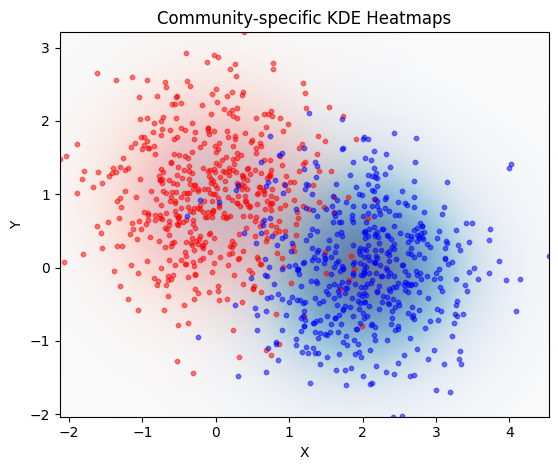

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Generate synthetic 2D data (two Gaussian clusters), kept close ---
np.random.seed(0)
n = 500
center1 = np.array([0, 1])
center2 = np.array([2, 0])
X1 = np.random.randn(n, 2) * 0.8 + center1
X2 = np.random.randn(n, 2) * 0.8 + center2

# --- Fit KDEs for each community ---
xy1 = np.vstack([X1[:, 0], X1[:, 1]])
xy2 = np.vstack([X2[:, 0], X2[:, 1]])
kde1 = gaussian_kde(xy1, bw_method='scott')
kde2 = gaussian_kde(xy2, bw_method='scott')

# --- Prepare evaluation grid ---
all_X = np.vstack([X1, X2])
xmin, xmax = all_X[:, 0].min(), all_X[:, 0].max()
ymin, ymax = all_X[:, 1].min(), all_X[:, 1].max()
xi = np.linspace(xmin, xmax, 200)
yi = np.linspace(ymin, ymax, 200)
Xg, Yg = np.meshgrid(xi, yi)
grid_coords = np.vstack([Xg.ravel(), Yg.ravel()])

kde1 = gaussian_kde(xy1, bw_method=0.8)
kde2 = gaussian_kde(xy2, bw_method=0.8)

# 2) Evaluate on grid
# ... build Xg, Yg exactly as before ...
grid = np.vstack([Xg.ravel(), Yg.ravel()])
Z1 = kde1(grid).reshape(Xg.shape)
Z2 = kde2(grid).reshape(Xg.shape)

# 3) Boost intensities
Z1 *= 100
Z2 *= 100

# 4) Plot
fig, ax = plt.subplots()
ax.imshow(Z1, origin='lower', extent=[xmin, xmax, ymin, ymax],
          cmap='Reds', alpha=0.6)
ax.imshow(Z2, origin='lower', extent=[xmin, xmax, ymin, ymax],
          cmap='Blues', alpha=0.6)

# Overlay scatter for context
ax.scatter(X1[:, 0], X1[:, 1], s=10, alpha=0.5, c='red')
ax.scatter(X2[:, 0], X2[:, 1], s=10, alpha=0.5, c='blue')

ax.set_title('Community-specific KDE Heatmaps')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
plt.show()


